In [31]:
# import libraries

from sys import displayhook
import matplotlib.pyplot as plt
from matplotlib.lines import lineStyles
from scipy.stats import zscore
import pandas as pd
import numpy as np

# load data
df = pd.read_csv("../data/raw/dataset.csv")

## impute missing values

In [32]:
list_missing = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']

for miss in list_missing:
    df[miss] = df[miss].fillna(df[miss].mode()[0])

for miss in list_missing:
    print(f"==={miss} count===")
    print(df[miss].isna().sum())

===Teacher_Quality count===
0
===Parental_Education_Level count===
0
===Distance_from_Home count===
0


## boxplot

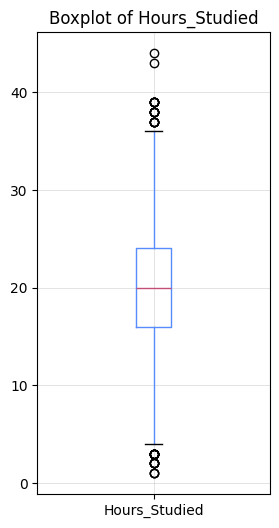

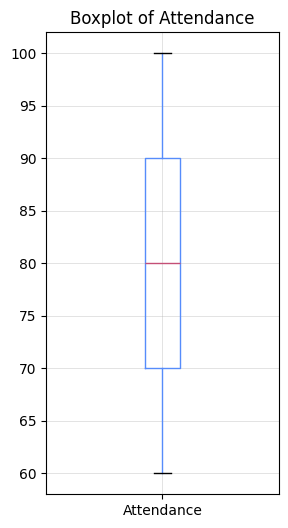

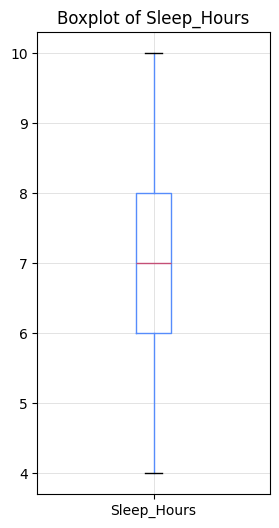

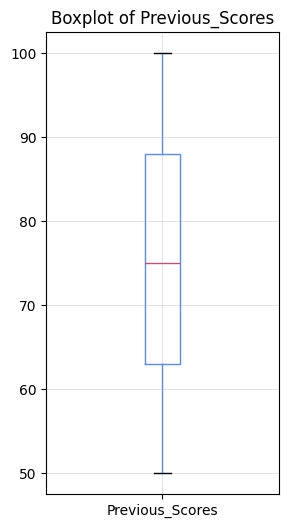

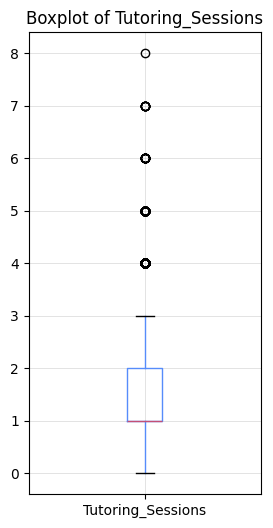

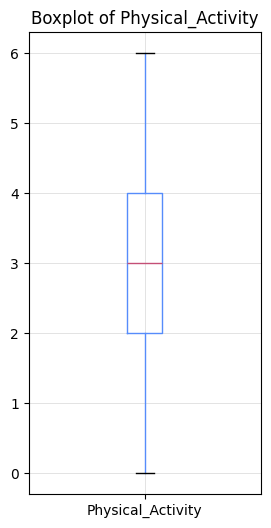

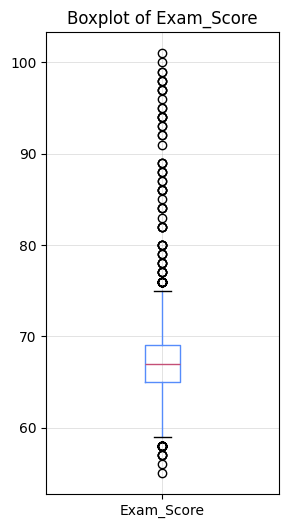

In [33]:
numerical_columns = df.select_dtypes(include="number").columns

for col in numerical_columns:
    plt.figure(figsize=(3, 6))
    df.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.show()


## compare IQR bounds and |z-score| > 3

In [34]:
numerical_columns = df.select_dtypes(include="number").columns

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - IQR * 1.5
    upper = Q3 + IQR * 1.5

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col, "→", len(outliers), "outliers")



Hours_Studied → 43 outliers
Attendance → 0 outliers
Sleep_Hours → 0 outliers
Previous_Scores → 0 outliers
Tutoring_Sessions → 430 outliers
Physical_Activity → 0 outliers
Exam_Score → 104 outliers


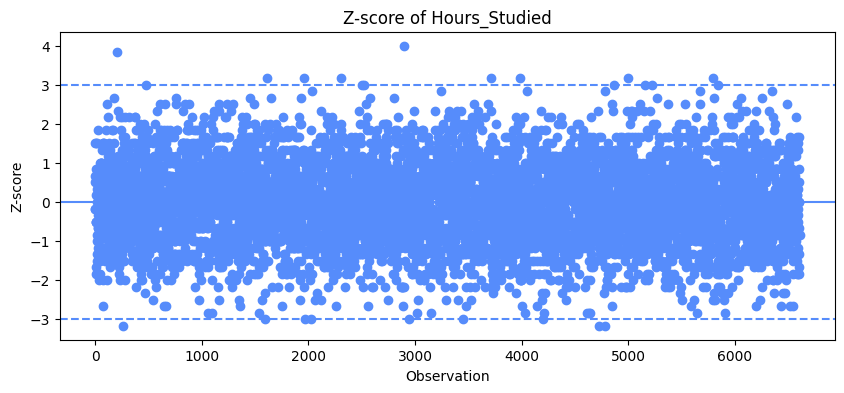

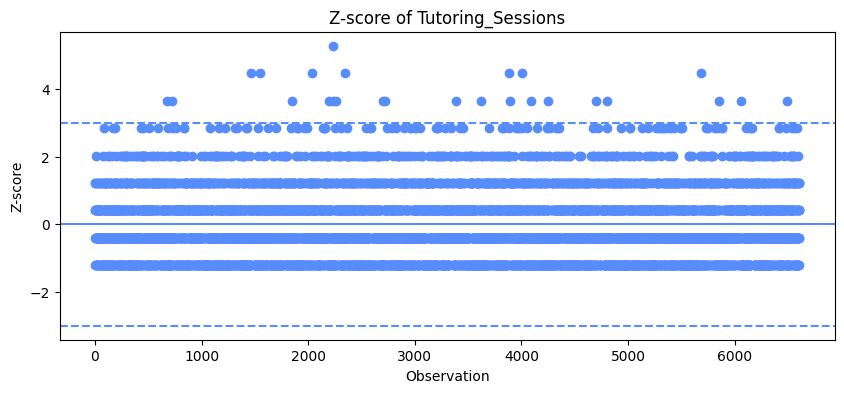

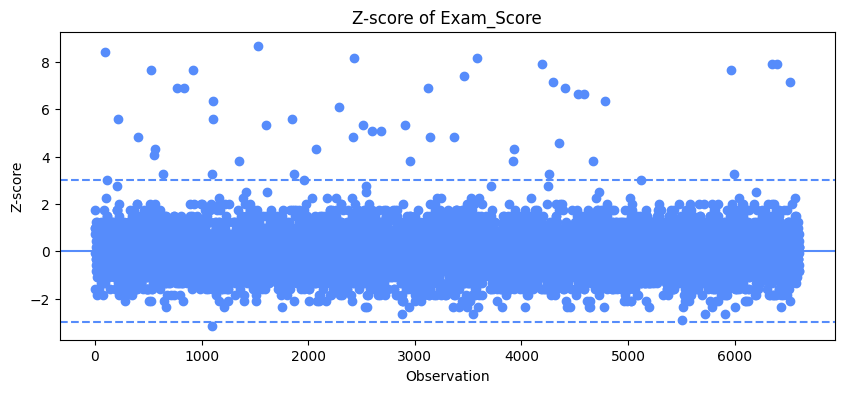

In [35]:
outlires_column = ["Hours_Studied", "Tutoring_Sessions", "Exam_Score"]

for out in outlires_column:

    df[f"{out}_Z"] = zscore(df[out])

    plt.figure(figsize=(10, 4))
    plt.scatter(df.index, df[f"{out}_Z"])


    plt.axhline(3, linestyle="--")
    plt.axhline(-3,linestyle="--")
    plt.axhline(0, linestyle="-")

    plt.title(f"Z-score of {out}")
    plt.xlabel("Observation")
    plt.ylabel("Z-score")

    plt.show()

## remove rows outside the IQR bounds for Exam_Score

In [36]:
before = len(df)

Q1 = df['Exam_Score'].quantile(0.25)
Q3 = df['Exam_Score'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - (IQR * 1.5)
upper = Q3 + (IQR * 1.5)

df = df[(df["Exam_Score"] >= lower) & (df["Exam_Score"] <= upper)]

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Rows deleted:", before - after)

Rows before: 6607
Rows after: 6503
Rows deleted: 104
